## Perfect Positive and Negative Correlation with one Outlier

In [8]:
from testdata import CORRELATED_UNCORRELATED_OUTLIER
x = CORRELATED_UNCORRELATED_OUTLIER.x
selectable_sups = CORRELATED_UNCORRELATED_OUTLIER.selectable_sups
props = CORRELATED_UNCORRELATED_OUTLIER.prop
len(x), len(props), len(selectable_sups)

(5, 24, 22)

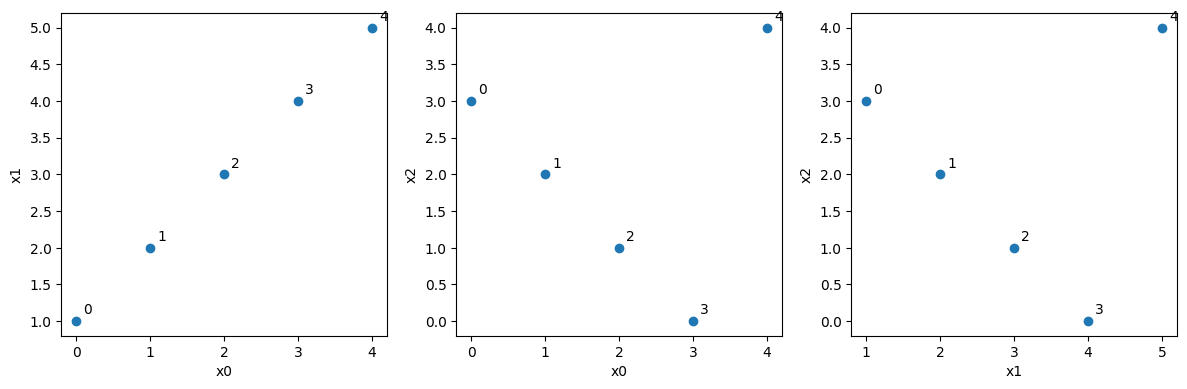

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import math

def plot_dataset_with_annotations(x, cols=3):
    """
    Plots all pairwise scatter plots of a dataset x with annotations.

    Args:
        x (ndarray): A (n, d) array representing n samples with d variables.
        plots_per_row (int): Number of plots per row in the subplot grid.
    """
    n, d = x.shape
    num_plots = d * (d - 1) // 2
    rows = math.ceil(num_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1 or cols == 1:
        axes = np.reshape(axes, (rows, cols))
    else:
        axes = np.array(axes)

    plot_idx = 0
    for i in range(d):
        for j in range(i + 1, d):
            row = plot_idx // cols
            col = plot_idx % cols
            ax = axes[row, col]
            ax.scatter(x[:, i], x[:, j])
            for k in range(n):
                ax.annotate(str(k), (x[k, i], x[k, j]), textcoords="offset points", xytext=(5,5), ha='left')
            ax.set_xlabel(f"x{i}")
            ax.set_ylabel(f"x{j}")
            plot_idx += 1

    # Hide unused subplots
    for idx in range(plot_idx, rows * cols):
        row = idx // cols
        col = idx % cols
        fig.delaxes(axes[row, col])

    plt.tight_layout()
    plt.show()

plot_dataset_with_annotations(x)


In [10]:
 # full_propositionalization(x)
for i in range(len(props)):
    print(props.str_from_prop(i))

x1 >= 4.000
x1 >= 3.000
x1 >= 2.000
x1 >= 1.000
x1 <= 0.000
x1 <= 1.000
x1 <= 2.000
x1 <= 3.000
x2 >= 5.000
x2 >= 4.000
x2 >= 3.000
x2 >= 2.000
x2 <= 1.000
x2 <= 2.000
x2 <= 3.000
x2 <= 4.000
x3 >= 4.000
x3 >= 3.000
x3 >= 2.000
x3 >= 1.000
x3 <= 0.000
x3 <= 1.000
x3 <= 2.000
x3 <= 3.000


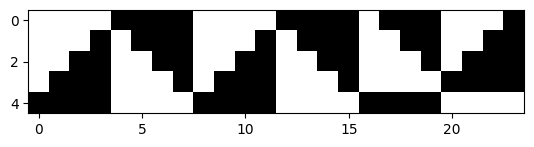

In [11]:
binary = props.binarize(x)
# plt.figure(figsize=(12, 20))
plt.imshow(binary, cmap='Greys', interpolation='none')
plt.show()